# Прогнозирование цен подержанных автомобилей (UK)

## Цель

Построить модель для оценки стоимости подержанного автомобиля на основе его характеристик и сравнить ансамблевые методы (бэггинг, блендинг, стекинг) по точности предсказаний.

## Бизнес-контекст

Платформа по продаже подержанных автомобилей в Великобритании. Продавцы выставляют машины по субъективным ценам - это приводит к завышенным или заниженным оценкам и замедляет сделки. Автоматическая оценка на основе реальных данных упростит ценообразование и повысит доверие покупателей.

## Задача

Обучить регрессионные модели (от линейной регрессии до стекинга) для предсказания цены автомобиля. Сравнить ансамбли по RMSE и MAPE, выбрать наилучший подход и сформулировать, какие методы дают максимальную выгоду по соотношению точность/сложность.

## Описание датасета

Датасет [Used Cars Prices in UK](https://www.kaggle.com/datasets/muhammadawaistayyab/used-cars-prices-in-uk) - объявления с autotrader.co.uk.

| Признак | Тип | Описание |
|---|---|---|
| Price | Числовой (целевой) | Цена в фунтах стерлингов (£) |
| Mileage(miles) | Числовой | Пробег в милях |
| Registration_Year | Числовой | Год регистрации |
| Previous Owners | Числовой | Количество предыдущих владельцев |
| Fuel type | Категориальный | Тип топлива (Petrol, Diesel и др.) |
| Body type | Категориальный | Тип кузова (Hatchback, Sedan и др.) |
| Engine | Категориальный | Объём двигателя в литрах (1.4L, 2.0L и др.) |
| Gearbox | Категориальный | Коробка передач (Manual, Automatic) |
| Seats | Числовой | Количество мест |
| Doors | Числовой | Количество дверей |
| Emission Class | Категориальный | Экологический класс |
| Service history | Категориальный | История обслуживания |
| Title | Текстовый | Заголовок объявления (удалён) |

Объём: 3 685 записей. 

#### Ограничения
Есть пропуски в нескольких столбцах.

## Подготовка данных

#### Загрузка и первичный осмотр
Вывод размера, типов данных, первых строк датафрейма, статистики важных признаков, а также корреляции признаков с целевой переменной.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

import warnings
warnings.filterwarnings("ignore")

In [28]:
df = pd.read_csv('used_cars_UK.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3685 entries, 0 to 3684
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3685 non-null   int64  
 1   title              3685 non-null   object 
 2   Price              3685 non-null   int64  
 3   Mileage(miles)     3685 non-null   int64  
 4   Registration_Year  3685 non-null   int64  
 5   Previous Owners    2276 non-null   float64
 6   Fuel type          3685 non-null   object 
 7   Body type          3685 non-null   object 
 8   Engine             3640 non-null   object 
 9   Gearbox            3685 non-null   object 
 10  Doors              3660 non-null   float64
 11  Seats              3650 non-null   float64
 12  Emission Class     3598 non-null   object 
 13  Service history    540 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 403.2+ KB


In [29]:
df.head()

,Unnamed: 0,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,0,SKODA Fabia,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,1,Vauxhall Corsa,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,2,Hyundai i30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,3,MINI Hatch,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,4,Vauxhall Corsa,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


In [19]:
print("Целевая переменная — Price (£):")
print(f"  Среднее: {df['Price'].mean():,.0f}")
print(f"  Медиана: {df['Price'].median():,.0f}")
print(f"  Мин/Макс: {df['Price'].min():,.0f} / {df['Price'].max():,.0f}")
print(f"  Стд. откл.: {df['Price'].std():,.0f}")

Целевая переменная — Price (£):
  Среднее: 5,787
  Медиана: 4,000
  Мин/Макс: 400 / 33,900
  Стд. откл.: 4,481


#### Выводы по целевой переменной
Средняя цена вдвое выше медианы — распределение смещено вправо: несколько дорогих автомобилей завышают среднее. Основная масса машин сосредоточена в диапазоне £2 000–8 000 с выбросами до £34 000.

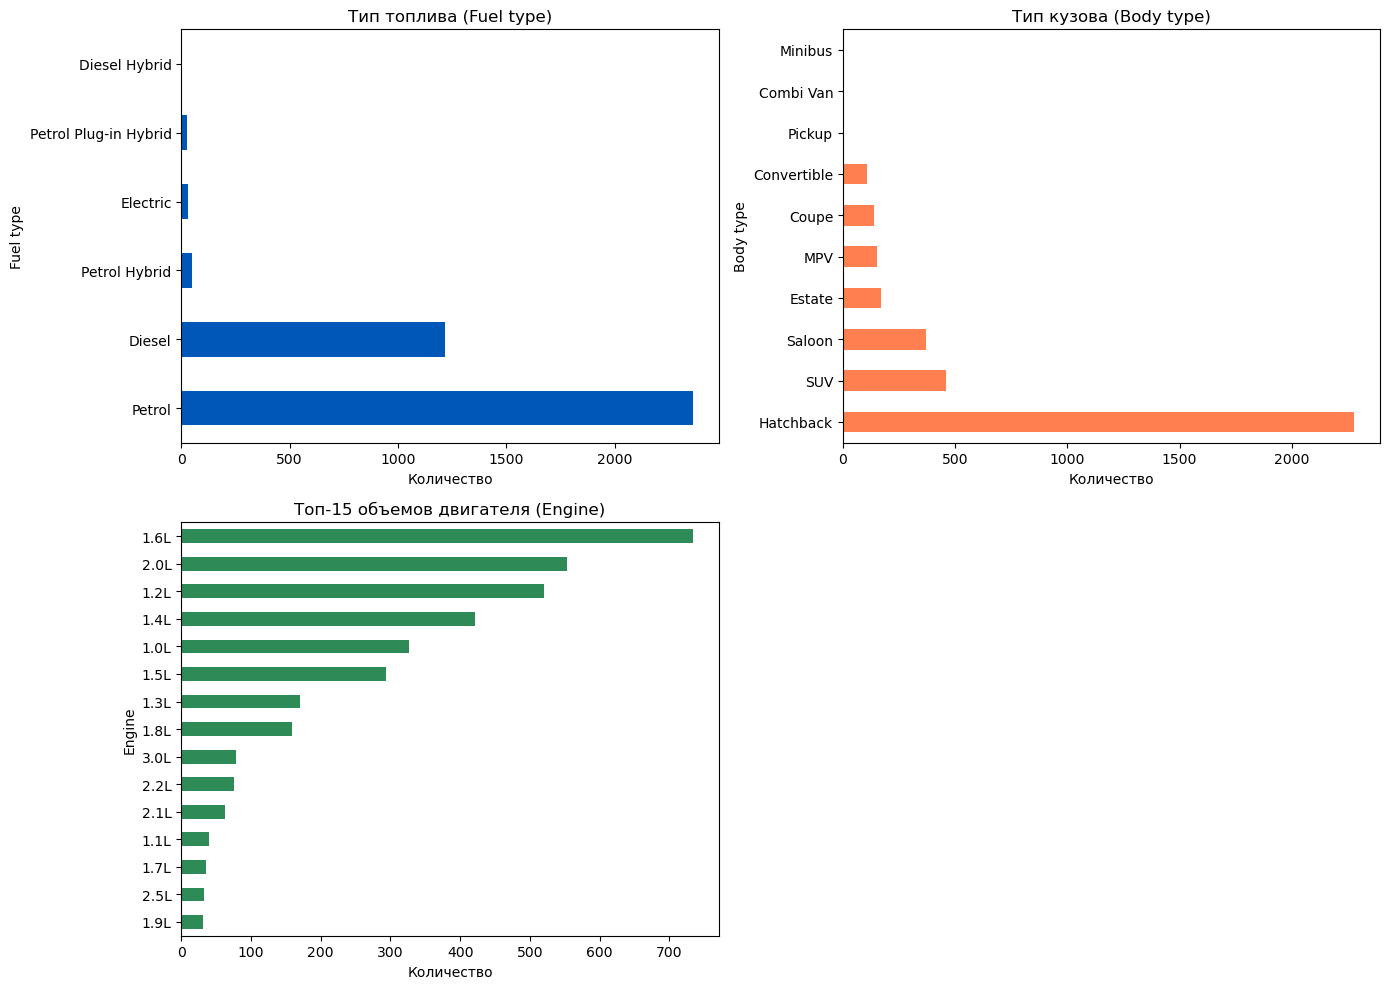

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['Fuel type'].value_counts().plot(kind='barh', ax=axes[0, 0], color='#0057B8')
axes[0, 0].set_title('Тип топлива (Fuel type)')
axes[0, 0].set_xlabel('Количество')

df['Body type'].value_counts().plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Тип кузова (Body type)')
axes[0, 1].set_xlabel('Количество')

df['Engine'].value_counts().head(15).sort_values().plot(kind='barh', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Топ-15 объемов двигателя (Engine)')
axes[1, 0].set_xlabel('Количество')

# Убираем пустой subplot
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

#### Корреляция признаков с ценой

Сильнее всего цена связана с годом регистрации (+0.72) — чем новее авто, тем дороже. Пробег и количество владельцев ожидаемо снижают цену (-0.50 и -0.48). Количество дверей и мест почти не влияют.

In [31]:
print("\nКорреляция признаков с ценой (Price):")
print(df[['Price', 'Mileage(miles)', 'Registration_Year', 'Previous Owners', 'Doors', 'Seats']].corr()['Price'].sort_values(ascending=False))


Корреляция признаков с ценой (Price):
Price                1.000000
Registration_Year    0.723880
Doors                0.113352
Seats               -0.027406
Previous Owners     -0.479424
Mileage(miles)      -0.500158
Name: Price, dtype: float64


#### Удаление неинформативных признаков
Удалены `Unnamed: 0` (технический индекс), `Service history` и `title` (не влияют на цену).

#### Заполнение пропусков
Выполнена проверка и обработка пропусков.
- Числовые: `Previous Owners` → 0 (нет истории владельцев), `Doors`, `Seats` → среднее значение.
- Категориальные: `Emission Class`, `Engine` → мода.


In [32]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Пропусков': missing, '%': missing_pct.round(1)})
print(missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False))

                 Пропусков     %
Service history       3145  85.3
Previous Owners       1409  38.2
Emission Class          87   2.4
Engine                  45   1.2
Seats                   35   0.9
Doors                   25   0.7


In [33]:
df = df.drop(['Unnamed: 0', 'Service history', 'title'], axis=1)

df['Previous Owners'] = df['Previous Owners'].fillna(0) # пустые знач-я в поле Previous Owners заполн. 0

numeric_columns = ['Doors', 'Seats']
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean()) # заполн. средними значениями
    
df['Emission Class'] = df['Emission Class'].fillna(df['Emission Class'].mode()[0]) # заполн. модой
df['Engine'] = df['Engine'].fillna(df['Engine'].mode()[0])

print(f"Осталось пропусков: {df.isnull().sum().sum()}")

Осталось пропусков: 0


#### Кодирование категориальных признаков
Редкие классы (встречаемость < 5%) объединены в `Other`. Категориальные признаки преобразованы в вещественные через One-Hot Encoding (`pd.get_dummies()`).

Особенность поля `Engine`: это объём двигателя в текстовом формате (например, "1.4L") — по сути числовой признак, но представлен как строка. В отличие от `Fuel type` или `Body type`, где значения — настоящие категории.

#### Разбиение на train/test
Данные разделены в пропорции 80/20 с `random_state=42`. Индексы сброшены.


In [8]:
categorical_columns = ['Fuel type', 'Body type', 'Engine', 'Gearbox', 'Emission Class']

for col in categorical_columns:
    value_counts = df[col].value_counts()
    threshold = len(df) * 0.05 # Пусть класс - редкий, если частота < 5% от общего коли-ва
    rare_categories = value_counts[value_counts < threshold].index
    df[col] = df[col].replace(rare_categories, 'Other') # объединяем редкие классы в "Other"

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True) # преобразуем категор-ые переменные в веществ-ые

X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # train/test как 80/20

# Обновляем индексы
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"X_train/X_test shape: {X_train.shape}/{X_test.shape}")
print(f"y_train/y_test shape: {y_train.shape}/{y_test.shape}")

X_train/X_test shape: (2948, 20)/(737, 20)
y_train/y_test shape: (2948,)/(737,)


In [9]:
df.head()

,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats,Fuel type_Other,Fuel type_Petrol,Body type_Other,Body type_SUV,...,Engine_1.2L,Engine_1.4L,Engine_1.5L,Engine_1.6L,Engine_2.0L,Engine_Other,Gearbox_Manual,Emission Class_Euro 5,Emission Class_Euro 6,Emission Class_Other
0,6900,70189,2016,3.0,5.0,5.0,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False
1,1495,88585,2008,4.0,3.0,5.0,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
2,949,137000,2011,0.0,5.0,5.0,False,True,False,False,...,False,True,False,False,False,False,True,True,False,False
3,2395,96731,2010,5.0,3.0,4.0,False,True,False,False,...,False,True,False,False,False,False,True,False,False,False
4,1000,85000,2013,0.0,5.0,5.0,False,False,False,False,...,False,False,False,False,False,True,True,True,False,False


## Baseline: одиночное решающее дерево

Обучено решающее дерево с параметрами по умолчанию. Это нижняя граница качества среди древесных моделей — дальнейшие ансамбли должны его превзойти.

In [10]:
baseline_tree = DecisionTreeRegressor(random_state=42)
baseline_tree.fit(X_train, y_train)

y_pred_baseline = baseline_tree.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mape_baseline = mean_absolute_percentage_error(y_test, y_pred_baseline)

print("Baseline: одиночное решающее дерево:")
print(f"RMSE: {rmse_baseline:.2f}")
print(f"MAPE: {mape_baseline:.4f} ({mape_baseline*100:.2f}%)")

Baseline: одиночное решающее дерево:
RMSE: 2231.56
MAPE: 0.3015 (30.15%)


## Bagging (бэггинг)

**BaggingRegressor** со стандартными параметрами и `random_state=42`. Базовые модели — решающие деревья.

Как работает: на N подвыборках обучаются независимые деревья, их предсказания усредняются. Это снижает дисперсию и переобучение, но базовые модели остаются одного типа.


In [11]:
bagging_model = BaggingRegressor(random_state=42) # созд. бэггинг с пар-ами по ум.
bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test) # предсказание

rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
mape_bagging = mean_absolute_percentage_error(y_test, y_pred_bagging)

print("Бэггинг решающих деревьев (с параметрами по ум.):")
print(f"RMSE: {rmse_bagging:.2f}")
print(f"MAPE: {mape_bagging:.4f} ({mape_bagging*100:.2f}%)")

Бэггинг решающих деревьев (с параметрами по ум.):
RMSE: 1910.85
MAPE: 0.2391 (23.91%)


## Сравнение одиночного дерева и бэггинга

Бэггинг ожидаемо превзошёл одиночное дерево: усреднение предсказаний по bootstrap-подвыборкам снизило дисперсию и улучшило обе метрики. Разрыв в MAPE особенно заметен — модель стала меньше ошибаться в процентах от цены, что важно для практического ценообразования.

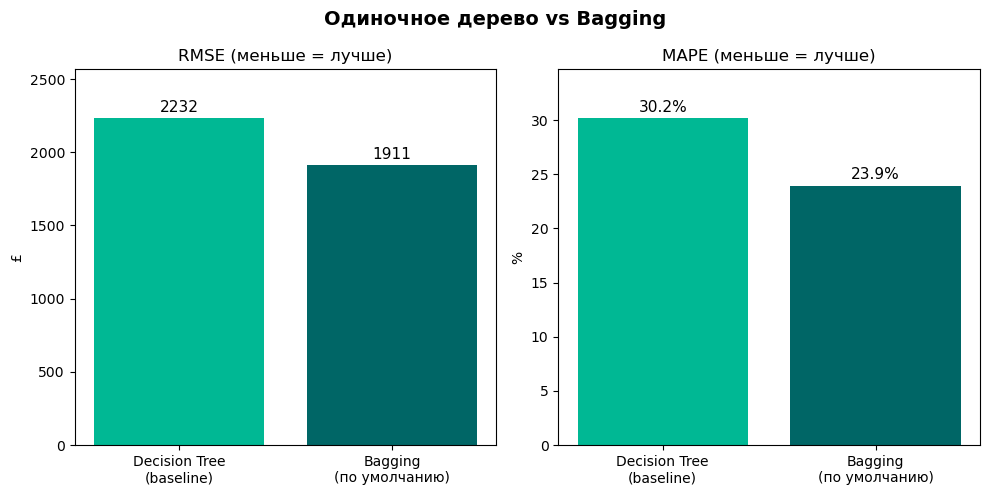

In [15]:
models = ['Decision Tree\n(baseline)', 'Bagging\n(по умолчанию)']
rmse_values = [rmse_baseline, rmse_bagging]
mape_values = [mape_baseline * 100, mape_bagging * 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

bars1 = ax1.bar(models, rmse_values, color=['#00B894', '#006666'])
ax1.set_title('RMSE (меньше = лучше)')
ax1.set_ylabel('£')
for bar, val in zip(bars1, rmse_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmse_values)*0.02, 
             f'{val:.0f}', ha='center', fontsize=11)
ax1.set_ylim(0, max(rmse_values) * 1.15)

bars2 = ax2.bar(models, mape_values, color=['#00B894', '#006666'])
ax2.set_title('MAPE (меньше = лучше)')
ax2.set_ylabel('%')
for bar, val in zip(bars2, mape_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mape_values)*0.02, 
             f'{val:.1f}%', ha='center', fontsize=11)
ax2.set_ylim(0, max(mape_values) * 1.15)

plt.suptitle('Одиночное дерево vs Bagging', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Подбор гиперпараметров Bagging (GridSearchCV)

Перебор по сетке: 
* `n_estimators` (10–200)
* `max_features` (0.2–1.0) 
* `max_samples` (0.5–1.0)
* `max_depth` (4–None). 

Оптимизация по отрицательному MSE (`neg_mean_squared_error`). GridSearchCV всегда максимизирует метрику, поэтому вместо MSE (где лучше — меньше) используют `neg_mean_squared_error` — отрицательный MSE (выше - лучше).  
Проведена 5-кратная кросс-валидация.


In [8]:
base_tree = DecisionTreeRegressor(random_state=42) # созд. базовое дерево
bagging = BaggingRegressor(estimator=base_tree, random_state=42) # созд. бэггинг регрессор

param_grid = { # Параметры для перебора
    'n_estimators': [10, 25, 50, 100, 200],
    'max_features': [0.2, 0.5, 0.7, 1.0],
    'max_samples': [0.5, 0.75, 1.0],
    'estimator__max_depth': [4, 6, 8, 10, 20, None]
}

grid_search = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train) # обуч. около 7 мин

print("Лучшие параметры:")
print(grid_search.best_params_)
print(f"\nЛучшее значение MSE (отрицательное): {grid_search.best_score_:.2f}")
print(f"Лучшее значение RMSE: {np.sqrt(-grid_search.best_score_):.2f}")

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Лучшие параметры:
{'estimator__max_depth': None, 'max_features': 0.7, 'max_samples': 0.75, 'n_estimators': 100}

Лучшее значение MSE (отрицательное): -2335739.93
Лучшее значение RMSE: 1528.31


#### Обучение Bagging с лучшими параметрами

Результат: RMSE снизился на 2.4%, MAPE практически не изменилась - гиперпараметры по умолчанию уже близки к оптимальным для этого датасета.

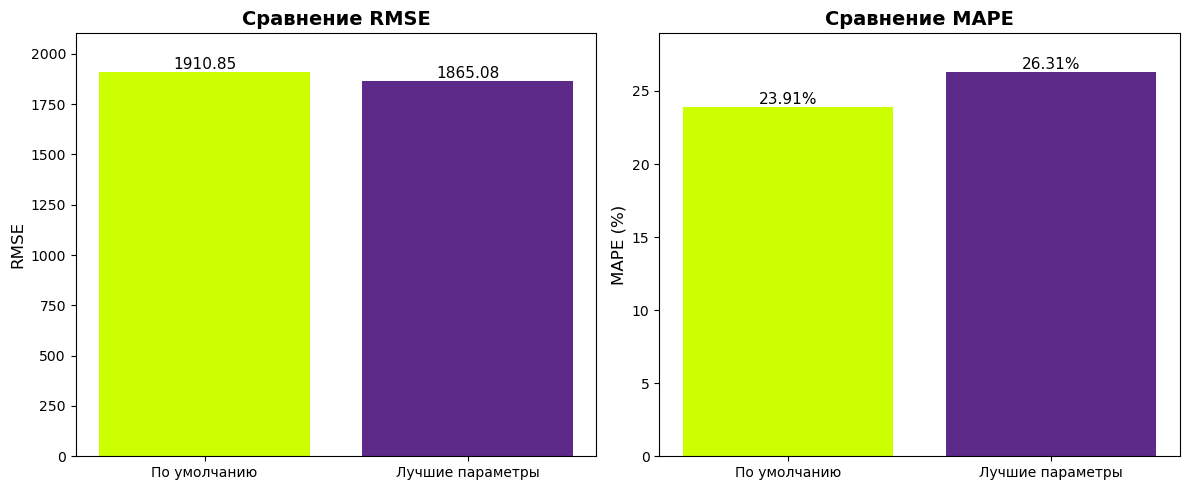

Улучшение:
  RMSE улучшился на 2.4%
  MAPE улучшился на -2.40%


In [97]:
best_bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=15, random_state=42),
    n_estimators=100,
    max_features=0.7,
    max_samples=0.75,
    random_state=42
)

best_bagging.fit(X_train, y_train)

y_pred_best = best_bagging.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mape_best = mean_absolute_percentage_error(y_test, y_pred_best)

models = ['По умолчанию', 'Лучшие параметры']
rmse_values = [rmse_bagging, rmse_best]
mape_values = [mape_bagging * 100, mape_best * 100]  

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#ccff00', '#5e2a8a']
bars1 = ax1.bar(models, rmse_values, color=colors)
ax1.set_title('Сравнение RMSE', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_ylim(0, max(rmse_values) * 1.1)

for bar, value in zip(bars1, rmse_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=11)

bars2 = ax2.bar(models, mape_values, color=colors)
ax2.set_title('Сравнение MAPE', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_ylim(0, max(mape_values) * 1.1)

for bar, value in zip(bars2, mape_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print("Улучшение:")
print(f"  RMSE улучшился на {(((rmse_bagging - rmse_best) / rmse_bagging) * 100):.1f}%")
print(f"  MAPE улучшился на {((mape_bagging - mape_best) * 100):.2f}%")

## Blending (блендинг)

Построен ансамбль из трёх разнотипных базовых моделей (линейная регрессия, kNN, решающее дерево) и мета-модели (линейная регрессия). Данные разбиваются: 80% — обучение базовых моделей, 20% — обучение мета-модели на их предсказаниях.

В отличие от бэггинга, модели разные — мета-модель учится взвешивать их предсказания. Проще стекинга, но чувствительнее к единственному разбиению.


In [10]:
lr_model = LinearRegression()
knn_model = KNeighborsRegressor()
dt_model = DecisionTreeRegressor(random_state=42)

lr_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)

print("Базовые модели:")
print("Линейная регрессия:")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  MAPE: {mape_lr:.4f} ({mape_lr*100:.2f}%)")
print("kNN:")
print(f"  RMSE: {rmse_knn:.2f}")
print(f"  MAPE: {mape_knn:.4f} ({mape_knn*100:.2f}%)")
print("Решающее дерево:")
print(f"  RMSE: {rmse_dt:.2f}")
print(f"  MAPE: {mape_dt:.4f} ({mape_dt*100:.2f}%)")

Базовые модели:
Линейная регрессия:
  RMSE: 2366.55
  MAPE: 0.3826 (38.26%)
kNN:
  RMSE: 3184.96
  MAPE: 0.5103 (51.03%)
Решающее дерево:
  RMSE: 2231.56
  MAPE: 0.3015 (30.15%)


In [11]:
X_base_train, X_meta_train, y_base_train, y_meta_train = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Обновляем индексы
X_base_train = X_base_train.reset_index(drop=True)
X_meta_train = X_meta_train.reset_index(drop=True)
y_base_train = y_base_train.reset_index(drop=True)
y_meta_train = y_meta_train.reset_index(drop=True)

In [12]:
lr_base = LinearRegression()
knn_base = KNeighborsRegressor()
dt_base = DecisionTreeRegressor(random_state=42)

lr_base.fit(X_base_train, y_base_train)
knn_base.fit(X_base_train, y_base_train)
dt_base.fit(X_base_train, y_base_train)

pred_lr_meta = lr_base.predict(X_meta_train)
pred_knn_meta = knn_base.predict(X_meta_train)
pred_dt_meta = dt_base.predict(X_meta_train)

X_meta_train_new = pd.DataFrame({ # Объединяем предсказания в один датафрейм
    'lr_pred': pred_lr_meta,
    'knn_pred': pred_knn_meta,
    'dt_pred': pred_dt_meta
})

print("Новый X_meta_train (предсказания базовых моделей):")
print(X_meta_train_new.head())

meta_model = LinearRegression() # обуч. мета-модель (лин. регрессию) на обновленном X_meta_train
meta_model.fit(X_meta_train_new, y_meta_train) 

# Делаем прогнозы базовых моделей на X_test
pred_lr_test = lr_base.predict(X_test)
pred_knn_test = knn_base.predict(X_test)
pred_dt_test = dt_base.predict(X_test)

# Объединяем прогнозы в DataFrame
X_meta_test = pd.DataFrame({
    'lr_pred': pred_lr_test,
    'knn_pred': pred_knn_test,
    'dt_pred': pred_dt_test
})

print("\nX_meta_test (предсказания базовых моделей на тесте):")
print(X_meta_test.head())

y_pred_blending = meta_model.predict(X_meta_test) # прогноз мета-модели

rmse_blending = np.sqrt(mean_squared_error(y_test, y_pred_blending))
mape_blending = mean_absolute_percentage_error(y_test, y_pred_blending)

print("\nРезультаты блендинга:")
print(f"RMSE: {rmse_blending:.2f}")
print(f"MAPE: {mape_blending:.4f} ({mape_blending*100:.2f}%)")

Новый X_meta_train (предсказания базовых моделей):
       lr_pred  knn_pred  dt_pred
0  3891.705112    3184.4   4000.0
1  3366.033802    6526.8   4350.0
2  3370.461513    2407.8   3000.0
3  4807.965552    8444.6   5500.0
4  2759.241886    3195.0   3195.0

X_meta_test (предсказания базовых моделей на тесте):
        lr_pred  knn_pred  dt_pred
0   2079.900956    2995.0   2995.0
1   9659.322572    6246.8  12895.0
2  15199.992318    6877.8  14577.0
3   2929.767542    1933.0   4000.0
4   1427.021438    2997.0   1295.0

Результаты блендинга:
RMSE: 2104.87
MAPE: 0.3188 (31.88%)


## Сравнение блендинга с другими моделями

Результат: блендинг ожидаемо лучше одиночных базовых моделей (kNN, дерево, линейная), но уступает даже стандартному бэггингу. Причина: фиксированное разбиение train_base/train_meta оставляет меньше данных для обучения, а 3 слабые модели не дают достаточно разнообразных мета-признаков.

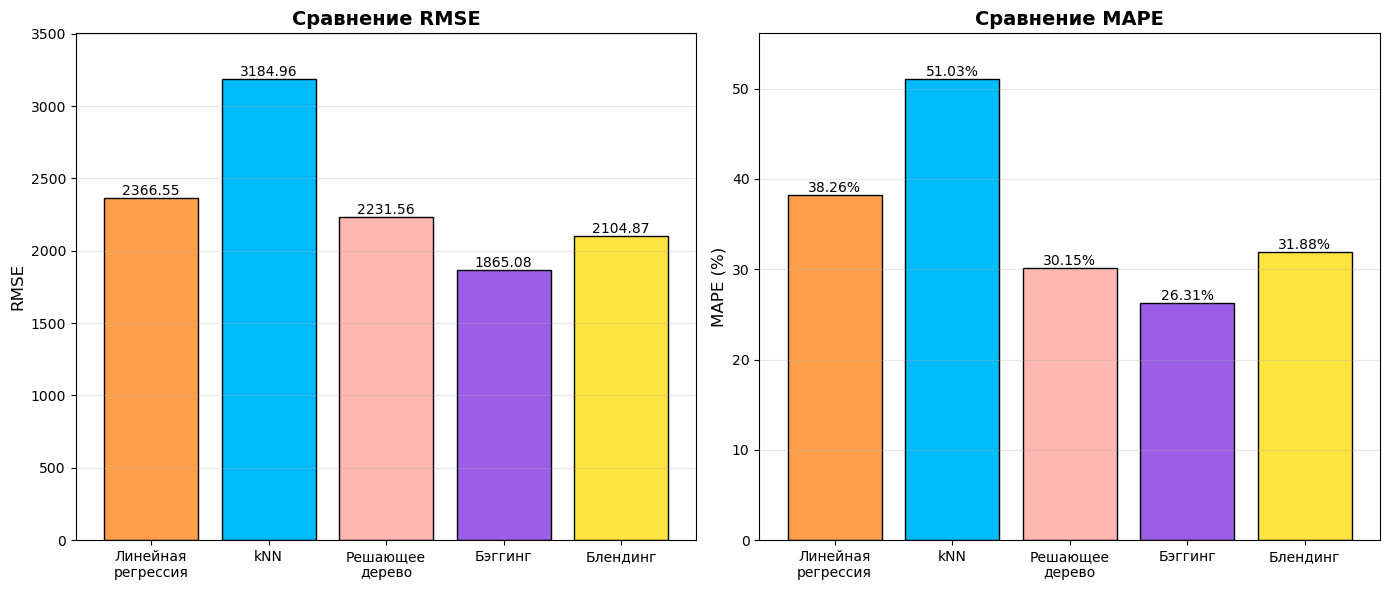


Лучшая модель по RMSE: Бэггинг (1865.08)
Лучшая модель по MAPE: Бэггинг (26.31%)


In [63]:
models_names = ['Линейная\nрегрессия', 'kNN', 'Решающее\nдерево', 'Бэггинг', 'Блендинг']
rmse_values_model = [rmse_lr, rmse_knn, rmse_dt, rmse_best, rmse_blending]
mape_values_model = [mape_lr * 100, mape_knn * 100, mape_dt * 100, mape_best * 100, mape_blending * 100]

colors = ['#FF9F4A', '#00BBF9', '#FFB7B2', '#9B5DE5', '#FEE440']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# colors = ['lightblue', 'lightgreen', 'lightcoral', 'gold', 'plum']
bars1 = ax1.bar(models_names, rmse_values_model, color=colors, edgecolor='black', linewidth=1)
ax1.set_title('Сравнение RMSE', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_ylim(0, max(rmse_values_model) * 1.1)
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars1, rmse_values_model):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=10)

bars2 = ax2.bar(models_names, mape_values_model, color=colors, edgecolor='black', linewidth=1)
ax2.set_title('Сравнение MAPE', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_ylim(0, max(mape_values_model) * 1.1)
ax2.grid(axis='y', alpha=0.3)

for bar, value in zip(bars2, mape_values_model):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

best_rmse_model = models_names[np.argmin(rmse_values_model)]
best_mape_model = models_names[np.argmin(mape_values_model)]
best_rmse_value = min(rmse_values_model)
best_mape_value = min(mape_values_model)
print(f"\nЛучшая модель по RMSE: {best_rmse_model} ({best_rmse_value:.2f})")
print(f"Лучшая модель по MAPE: {best_mape_model} ({best_mape_value:.2f}%)")

## Stacking (стекинг)

Стекинг — ансамблевый метод: предсказания нескольких разнотипных моделей объединяются и подаются на вход финальной мета-модели. В отличие от блендинга, в стекинге мета-признаки создаются через кросс-валидацию (cv=5): базовые модели предсказывают на данных, которые не видели при обучении — это даёт более «честные» и устойчивые мета-признаки.

Базовые модели: линейная регрессия, kNN, решающее дерево. Мета-модель: линейная регрессия. Реализован через `StackingRegressor`.

In [14]:
base_models = [
    ('linear_regression', LinearRegression()),
    ('knn', KNeighborsRegressor()),
    ('decision_tree', DecisionTreeRegressor(random_state=42))
]

meta_model = LinearRegression() # созд. мета-модель (лин. регрессия)

stacking_model = StackingRegressor( # созд. стекинг регрессор
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

stacking_model.fit(X_train, y_train)

y_pred_stacking = stacking_model.predict(X_test)
rmse_stacking = np.sqrt(mean_squared_error(y_test, y_pred_stacking))
mape_stacking = mean_absolute_percentage_error(y_test, y_pred_stacking)

print("Стекинг:")
print(f"RMSE: {rmse_stacking:.2f}")
print(f"MAPE: {mape_stacking:.4f} ({mape_stacking*100:.2f}%)")

Стекинг:
RMSE: 2065.56
MAPE: 0.2973 (29.73%)


## Сравнение стекинга с другими моделями

Стекинг закономерно обошёл блендинг за счёт кросс-валидации мета-признаков, но всё ещё заметно уступает даже базовому бэггингу. Три слабые базовые модели (линейная, kNN, дерево) не дают стекингу достаточного преимущества - требуется более сильный состав ансамбля.

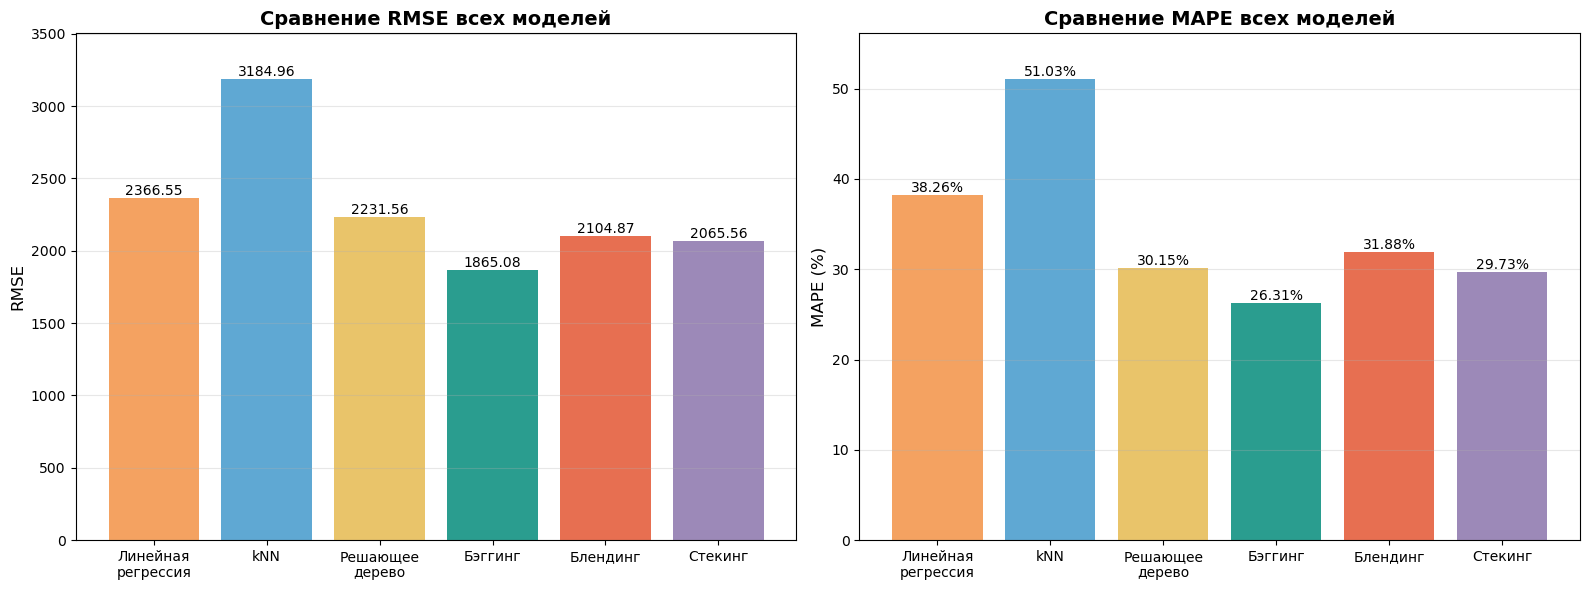


Лучшая модель по RMSE: Бэггинг (1865.08)
Лучшая модель по MAPE: Бэггинг (26.31%)


In [99]:
models_names = ['Линейная\nрегрессия', 'kNN', 'Решающее\nдерево', 'Бэггинг', 'Блендинг', 'Стекинг']
rmse_values_all = [rmse_lr, rmse_knn, rmse_dt, rmse_best, rmse_blending, rmse_stacking]
mape_values_all = [mape_lr * 100, mape_knn * 100, mape_dt * 100, mape_best * 100, mape_blending * 100, mape_stacking * 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#F4A261', '#5FA8D3', '#E9C46A', '#2A9D8F', '#E76F51', '#9C89B8']

bars1 = ax1.bar(models_names, rmse_values_all, color=colors)
ax1.set_title('Сравнение RMSE всех моделей', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_ylim(0, max(rmse_values_all) * 1.1)
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars1, rmse_values_all):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=10)

bars2 = ax2.bar(models_names, mape_values_all, color=colors)
ax2.set_title('Сравнение MAPE всех моделей', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_ylim(0, max(mape_values_all) * 1.1)
ax2.grid(axis='y', alpha=0.3)

for bar, value in zip(bars2, mape_values_all):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

best_rmse_model = models_names[np.argmin(rmse_values_all)]
best_mape_model = models_names[np.argmin(mape_values_all)]
best_rmse_value = min(rmse_values_all)
best_mape_value = min(mape_values_all)
print(f"\nЛучшая модель по RMSE: {best_rmse_model} ({best_rmse_value:.2f})")
print(f"Лучшая модель по MAPE: {best_mape_model} ({best_mape_value:.2f}%)")

#### Стекинг с бэггингом в базовых моделях

В базовые модели для стекинга добавлен тюнингованный бэггинг.  


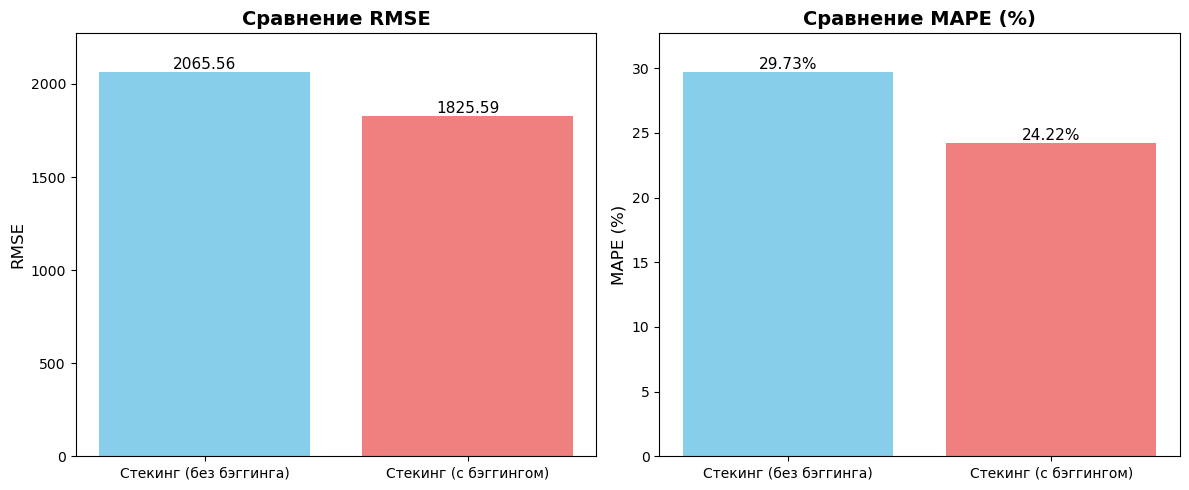


После добавления бэггинга:
  RMSE улучшился на: 239.96 (11.6%)
  MAPE улучшился на: 5.51%


In [87]:
base_models_with_bagging = [
    ('linear_regression', LinearRegression()),
    ('knn', KNeighborsRegressor()),
    ('decision_tree', DecisionTreeRegressor(random_state=42)),
    ('bagging', best_bagging)  # добавляем лучшую бэггинг модель
]

meta_model = LinearRegression()

stacking_with_bagging = StackingRegressor( # созд. стекинг регрессор с добавленным бэггингом
    estimators=base_models_with_bagging,
    final_estimator=meta_model,
    cv=5
)

stacking_with_bagging.fit(X_train, y_train)

y_pred_stacking_bagging = stacking_with_bagging.predict(X_test)
rmse_stacking_bagging = np.sqrt(mean_squared_error(y_test, y_pred_stacking_bagging))
mape_stacking_bagging = mean_absolute_percentage_error(y_test, y_pred_stacking_bagging)

# Данные для графиков
models = ['Стекинг (без бэггинга)', 'Стекинг (с бэггингом)']
rmse_values = [rmse_stacking, rmse_stacking_bagging]
mape_values = [mape_stacking * 100, mape_stacking_bagging * 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars1 = ax1.bar(models, rmse_values, color=['skyblue', 'lightcoral'])
ax1.set_title('Сравнение RMSE', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_ylim(0, max(rmse_values) * 1.1)

for bar, value in zip(bars1, rmse_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=11)

bars2 = ax2.bar(models, mape_values, color=['skyblue', 'lightcoral'])
ax2.set_title('Сравнение MAPE (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_ylim(0, max(mape_values) * 1.1)

for bar, value in zip(bars2, mape_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

rmse_improvement = rmse_stacking - rmse_stacking_bagging
rmse_improvement_percent = (rmse_improvement / rmse_stacking) * 100
mape_improvement_percent = (mape_stacking - mape_stacking_bagging) * 100

print(f"\nПосле добавления бэггинга:")
print(f"  RMSE улучшился на: {rmse_improvement:.2f} ({rmse_improvement_percent:.1f}%)")
if mape_improvement_percent >= 0:
    print(f"  MAPE улучшился на: {mape_improvement_percent:.2f}%")
else:
    print(f"  MAPE ухудшился на: {abs(mape_improvement_percent):.2f}%")

#### Вывод

Результат: это дало значительный прирост. Сильная модель в ансамбле «вытягивает» слабые - мета-модель получает более качественные и разнообразные мета-признаки для усреднения.

Добавление бэггинга в базовые модели стекинга **значительно улучшило качество** модели: RMSE и MAPE снизились на несколько процентов. Объяснение:
- Бэггинг за счёт усреднения по bootstrap-выборкам менее склонен к переобучению, чем одиночное дерево, — его предсказания стабильнее.
- Разнообразие моделей: простая линейная модель, kNN, дерево и устойчивый ансамбль деревьев — мета-модель получает принципиально разные «взгляды» на данные.
- Сильная модель в ансамбле «вытягивает» слабые — мета-модель получает более качественные и разнообразные мета-признаки и находит оптимальные веса для их комбинации.


## Тюнинг решающего дерева

Выполнен подбор гиперпараметров `max_depth`, `min_samples_split`, `max_features` через `GridSearchCV` на всём `X_train`. Цель — найти оптимальный баланс между точностью и переобучением для одиночного дерева, чтобы в дальнейшем использовать его в стекинге.


In [17]:
dt_for_tuning = DecisionTreeRegressor(random_state=42)

param_grid_dt = { # Пар-ры для перебора
    'max_depth': [4, 6, 8, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.7, 1.0]
}

grid_search_dt = GridSearchCV(
    estimator=dt_for_tuning,
    param_grid=param_grid_dt,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

print("Лучшие параметры для решающего дерева:")
print(grid_search_dt.best_params_)
print(f"\nЛучшее значение MSE (отрицательное): {grid_search_dt.best_score_:.2f}")
print(f"Лучшее значение RMSE: {np.sqrt(-grid_search_dt.best_score_):.2f}")

Fitting 5 folds for each of 168 candidates, totalling 840 fits
Лучшие параметры для решающего дерева:
{'max_depth': 15, 'max_features': 0.7, 'min_samples_split': 20}

Лучшее значение MSE (отрицательное): -3235688.58
Лучшее значение RMSE: 1798.80


#### Результат подбора (копия)  
Лучшие параметры для решающего дерева:
{'max_depth': 15, 'max_features': 0.7, 'min_samples_split': 20}  

Лучшее значение MSE (отрицательное): -3235688.58  
Лучшее значение RMSE: 1798.80

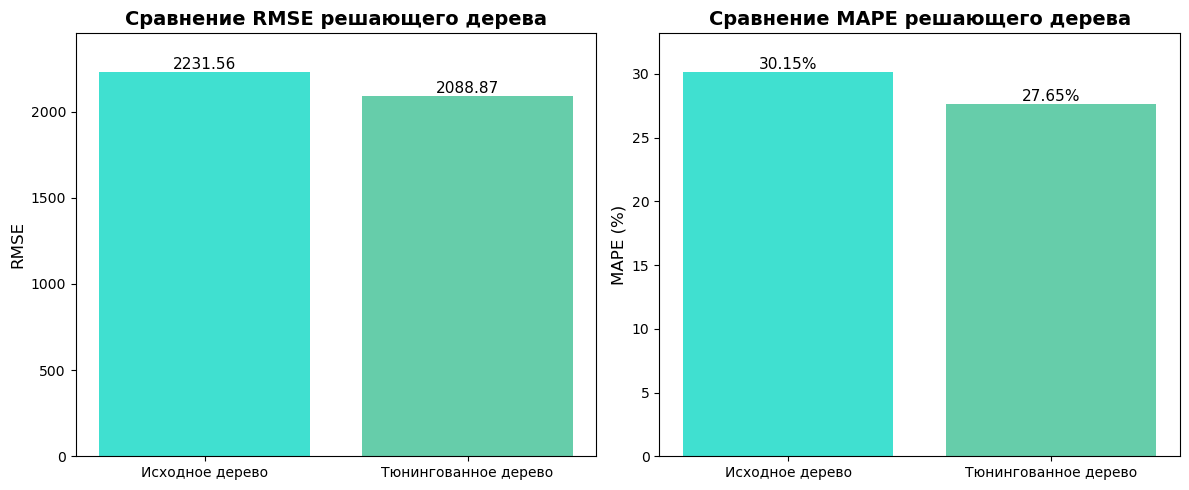


Улучшение после тюнинга:
  RMSE улучшился на: 142.69 (6.4%)
  MAPE улучшился на: 2.51%


In [100]:
best_dt = grid_search_dt.best_estimator_ # обуч. дерево с лучшими параметрами

y_pred_dt_tuned = best_dt.predict(X_test)
rmse_dt_tuned = np.sqrt(mean_squared_error(y_test, y_pred_dt_tuned))
mape_dt_tuned = mean_absolute_percentage_error(y_test, y_pred_dt_tuned)

models = ['Исходное дерево', 'Тюнингованное дерево']
rmse_values = [rmse_dt, rmse_dt_tuned]
mape_values = [mape_dt * 100, mape_dt_tuned * 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['turquoise', 'mediumaquamarine']
bars1 = ax1.bar(models, rmse_values, color=colors)
ax1.set_title('Сравнение RMSE решающего дерева', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_ylim(0, max(rmse_values) * 1.1)

for bar, value in zip(bars1, rmse_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=11)

bars2 = ax2.bar(models, mape_values, color=colors)
ax2.set_title('Сравнение MAPE решающего дерева', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_ylim(0, max(mape_values) * 1.1)

for bar, value in zip(bars2, mape_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

rmse_improvement = rmse_dt - rmse_dt_tuned
rmse_improvement_percent = (rmse_improvement / rmse_dt) * 100
mape_improvement = (mape_dt - mape_dt_tuned) * 100

print(f"\nУлучшение после тюнинга:")
if rmse_improvement >= 0:
    print(f"  RMSE улучшился на: {rmse_improvement:.2f} ({rmse_improvement_percent:.1f}%)")
else:
    print(f"  RMSE ухудшился на: {abs(rmse_improvement):.2f} ({abs(rmse_improvement_percent):.1f}%)")
if mape_improvement >= 0:
    print(f"  MAPE улучшился на: {mape_improvement:.2f}%")
else:
    print(f"  MAPE ухудшился на: {abs(mape_improvement):.2f}%")

#### Эффект тюнинга дерева

Для одиночного дерева после подбора гиперпараметров качество выросло: RMSE и MAPE снизились на несколько процентов. Ограничение глубины и листьев уменьшило переобучение.

На стекинг тюнинг напрямую не повлиял — он обучен с исходным деревом (без тюнинга). Замена на `best_dt` в базовых моделях могла бы дать дополнительный прирост, но отдельно не тестировалась.


## Смена мета-модели в стекинге

LinearRegression заменена на Ridge и RandomForest в качестве мета-модели стекинга, чтобы проверить, улучшит ли более сложный алгоритм финальное усреднение предсказаний. 


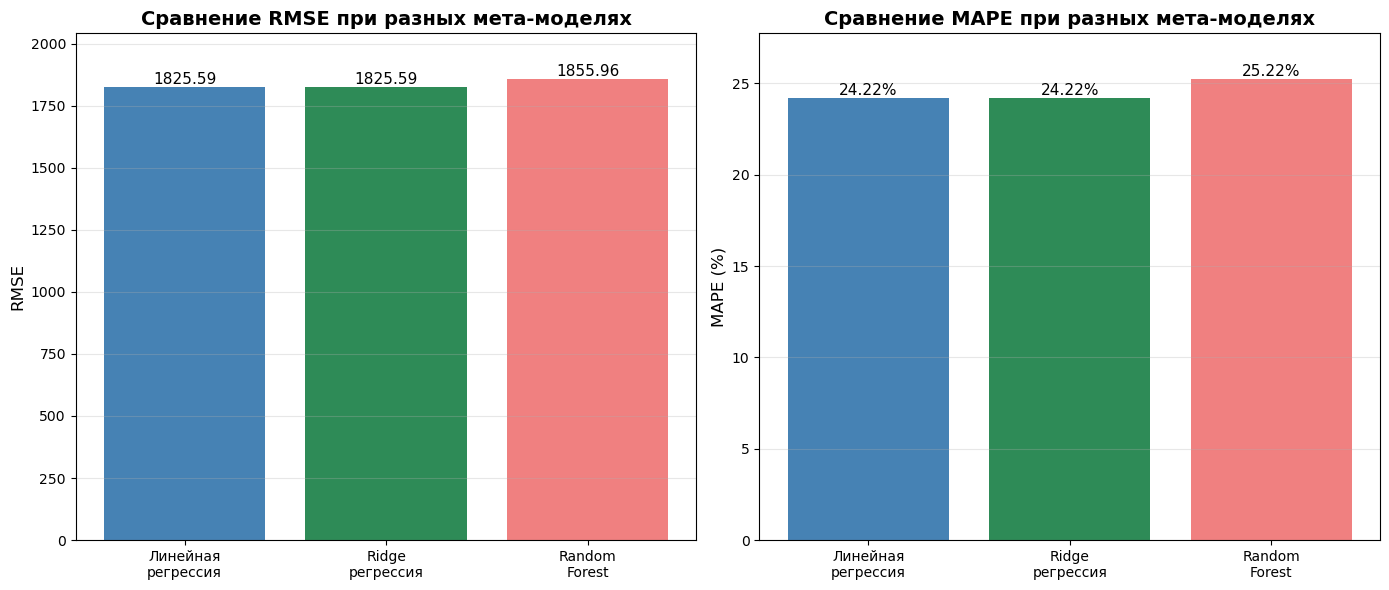


Лучшая по RMSE: Линейная
регрессия (1825.59)
Лучшая по MAPE: Линейная
регрессия (24.22%)

Изменение качества:
Ridge vs Linear Regression:
  RMSE: -0.00 (-0.0%)
  MAPE: -0.00%
Random Forest vs Linear Regression:
  RMSE: -30.37 (-1.7%)
  MAPE: -1.00%


In [84]:
base_models_for_stacking = [
    ('linear_regression', LinearRegression()),
    ('knn', KNeighborsRegressor()),
    ('decision_tree', DecisionTreeRegressor(random_state=42)),
    ('bagging', best_bagging)
]

# Вариант 1: Мета-модель - Ridge регрессия
meta_model_ridge = Ridge(alpha=1.0, random_state=42)

stacking_ridge = StackingRegressor(
    estimators=base_models_for_stacking,
    final_estimator=meta_model_ridge,
    cv=5
)

stacking_ridge.fit(X_train, y_train)
y_pred_stacking_ridge = stacking_ridge.predict(X_test)

rmse_stacking_ridge = np.sqrt(mean_squared_error(y_test, y_pred_stacking_ridge))
mape_stacking_ridge = mean_absolute_percentage_error(y_test, y_pred_stacking_ridge)

# Вариант 2: Мета-модель - Random Forest
meta_model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

stacking_rf = StackingRegressor(
    estimators=base_models_for_stacking,
    final_estimator=meta_model_rf,
    cv=5
)

stacking_rf.fit(X_train, y_train)
y_pred_stacking_rf = stacking_rf.predict(X_test)

rmse_stacking_rf = np.sqrt(mean_squared_error(y_test, y_pred_stacking_rf))
mape_stacking_rf = mean_absolute_percentage_error(y_test, y_pred_stacking_rf)

models_meta = ['Линейная\nрегрессия', 'Ridge\nрегрессия', 'Random\nForest']
rmse_meta_values = [rmse_stacking_bagging, rmse_stacking_ridge, rmse_stacking_rf]
mape_meta_values = [mape_stacking_bagging * 100, mape_stacking_ridge * 100, mape_stacking_rf * 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors_meta = ['steelblue', 'seagreen', 'lightcoral']
bars1 = ax1.bar(models_meta, rmse_meta_values, color=colors_meta)
ax1.set_title('Сравнение RMSE при разных мета-моделях', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_ylim(0, max(rmse_meta_values) * 1.1)
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars1, rmse_meta_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=11)

bars2 = ax2.bar(models_meta, mape_meta_values, color=colors_meta)
ax2.set_title('Сравнение MAPE при разных мета-моделях', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_ylim(0, max(mape_meta_values) * 1.1)
ax2.grid(axis='y', alpha=0.3)

for bar, value in zip(bars2, mape_meta_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

best_rmse_idx = np.argmin(rmse_meta_values)
best_mape_idx = np.argmin(mape_meta_values)

print(f"\nЛучшая по RMSE: {models_meta[best_rmse_idx]} ({rmse_meta_values[best_rmse_idx]:.2f})")
print(f"Лучшая по MAPE: {models_meta[best_mape_idx]} ({mape_meta_values[best_mape_idx]:.2f}%)")

print("\nИзменение качества:")
print(f"Ridge vs Linear Regression:")
print(f"  RMSE: {rmse_stacking_bagging - rmse_stacking_ridge:.2f} ({(rmse_stacking_bagging - rmse_stacking_ridge)/rmse_stacking_bagging*100:.1f}%)")
print(f"  MAPE: {(mape_stacking_bagging - mape_stacking_ridge)*100:.2f}%")

print(f"Random Forest vs Linear Regression:")
print(f"  RMSE: {rmse_stacking_bagging - rmse_stacking_rf:.2f} ({(rmse_stacking_bagging - rmse_stacking_rf)/rmse_stacking_bagging*100:.1f}%)")
print(f"  MAPE: {(mape_stacking_bagging - mape_stacking_rf)*100:.2f}%")

#### Выводы

Для Ridge качество не изменилось, Random Forest ухудшил качество. Линейная регрессия осталась лучшей мета-моделью.  

Причина: мета-признаков всего 4 - Random Forest склонен к переобучению на малом числе входов. Простая линейная модель лучше обобщает и не переобучается на малом количестве признаков, когда базовые предсказания уже хорошо скоррелированы с целью.


#### Тюнинг kNN и Ridge

Подобраны гиперпараметры: kNN (5 соседей, Manhattan-расстояние), Ridge (alpha=0.1). Линейная регрессия не имеет гиперпараметров, подбор не требуется. Результаты использованы в финальном стекинге.

In [20]:
print("Подбор параметров для kNN...")
knn_tuning = KNeighborsRegressor()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 - манхэттенское расстояние, 2 - евклидово
}

grid_knn = GridSearchCV(
    estimator=knn_tuning,
    param_grid=param_grid_knn,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print(f"Лучшие параметры kNN: {grid_knn.best_params_}")
print(f"Лучший RMSE: {np.sqrt(-grid_knn.best_score_):.2f}\n")

print("Подбор параметров для Ridge...")
ridge_tuning = Ridge(random_state=42)

param_grid_ridge = {
    'alpha': [0.1, 1.0, 10.0, 100.0]
}

grid_ridge = GridSearchCV(
    estimator=ridge_tuning,
    param_grid=param_grid_ridge,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_
print(f"Лучшие параметры Ridge: {grid_ridge.best_params_}")
print(f"Лучший RMSE: {np.sqrt(-grid_ridge.best_score_):.2f}\n")

# Линейная регрессия не требует подбора параметров (нет гиперпараметров)

Подбор параметров для kNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Лучшие параметры kNN: {'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
Лучший RMSE: 3003.77

Подбор параметров для Ridge...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие параметры Ridge: {'alpha': 0.1}
Лучший RMSE: 2183.56



## Финальный стекинг с тюнингованными моделями

Базовый kNN заменен на tuned-версию, а мета-модель - на Ridge с подобранным гиперпараметром alpha. 

Результат: замена kNN на tuned-версию и Ridge как мета-модель не дали значимого прироста: RMSE и MAPE остались на уровне исходного стекинга с бэггингом. Это подтверждает, что основной вклад в качество вносит бэггинг, а не точная настройка слабых моделей.

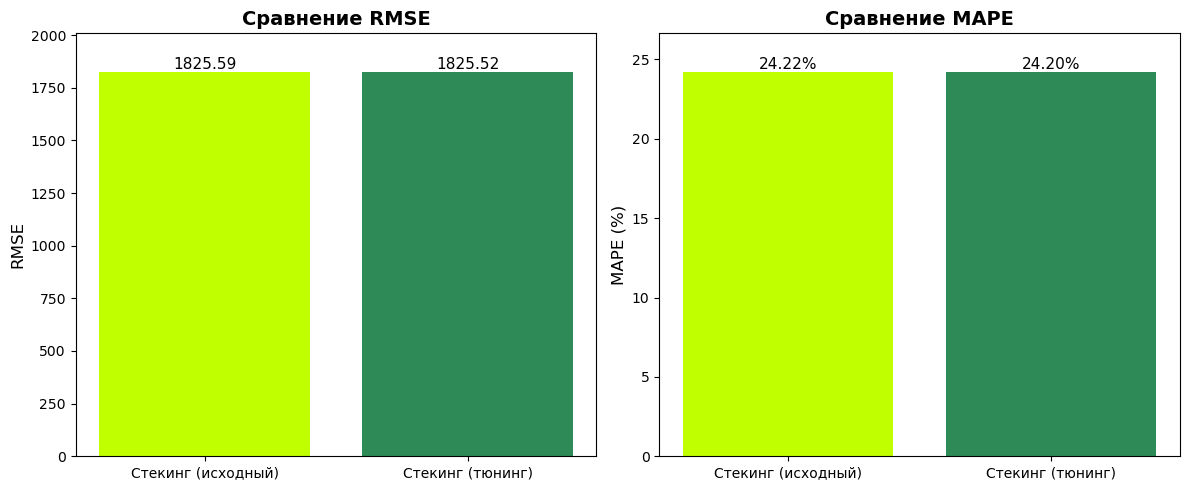

После тюнинга:
  RMSE улучшился на 0.07 (0.0%)
  MAPE улучшился на 0.02%


In [102]:
base_models_tuned = [ # созд. стекинг с тюнингованными моделями
    ('linear_regression', LinearRegression()),  # у лин. регрессии нет гиперпараметров
    ('knn_tuned', best_knn),
    ('decision_tree', DecisionTreeRegressor(random_state=42)),
    ('bagging', best_bagging)
]

stacking_tuned = StackingRegressor( # Стекинг с тюнингованной Ridge мета-моделью
    estimators=base_models_tuned,
    final_estimator=best_ridge,
    cv=5
)

stacking_tuned.fit(X_train, y_train)
y_pred_stacking_tuned = stacking_tuned.predict(X_test)

rmse_stacking_tuned = np.sqrt(mean_squared_error(y_test, y_pred_stacking_tuned))
mape_stacking_tuned = mean_absolute_percentage_error(y_test, y_pred_stacking_tuned)

models_compare = ['Стекинг (исходный)', 'Стекинг (тюнинг)']
rmse_compare = [rmse_stacking_bagging, rmse_stacking_tuned]
mape_compare = [mape_stacking_bagging * 100, mape_stacking_tuned * 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#c0ff00', '#2e8b57']
bars1 = ax1.bar(models_compare, rmse_compare, color=colors)
ax1.set_title('Сравнение RMSE', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_ylim(0, max(rmse_compare) * 1.1)

for bar, value in zip(bars1, rmse_compare):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=11)

bars2 = ax2.bar(models_compare, mape_compare, color=colors)
ax2.set_title('Сравнение MAPE', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_ylim(0, max(mape_compare) * 1.1)

for bar, value in zip(bars2, mape_compare):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

rmse_improve = rmse_stacking_bagging - rmse_stacking_tuned
mape_improve = (mape_stacking_bagging - mape_stacking_tuned) * 100
print(f"После тюнинга:")
print(f"  RMSE улучшился на {rmse_improve:.2f} ({rmse_improve/rmse_stacking_bagging*100:.1f}%)")
print(f"  MAPE улучшился на {mape_improve:.2f}%")

## Итоговое сравнение всех моделей

График и таблица всех моделей по RMSE и MAPE.

ИТОГОВЫЕ РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ

1. БАЗОВЫЕ МОДЕЛИ:
Линейная регрессия:      RMSE = 2366.55, MAPE = 38.26%
kNN:                     RMSE = 3184.96, MAPE = 51.03%
Решающее дерево:         RMSE = 2231.56, MAPE = 30.15%

2. БЭГГИНГ:
Бэггинг (по умолчанию):  RMSE = 1910.85, MAPE = 23.91%
Бэггинг (лучший):        RMSE = 1865.08, MAPE = 26.31%

3. БЛЕНДИНГ:             RMSE = 2104.87, MAPE = 31.88%

4. СТЕКИНГ:
Стекинг (без бэггинга):  RMSE = 2065.56, MAPE = 29.73%
Стекинг (с бэггингом):   RMSE = 1825.59, MAPE = 24.22%
Стекинг (Ridge):         RMSE = 1825.59, MAPE = 24.22%
Стекинг (Random Forest): RMSE = 1855.96, MAPE = 25.22%
Стекинг (тюнинг):        RMSE = 1825.52, MAPE = 24.20%

5. ДЕРЕВО:
Тюнингованное дерево:    RMSE = 2088.87, MAPE = 27.65%


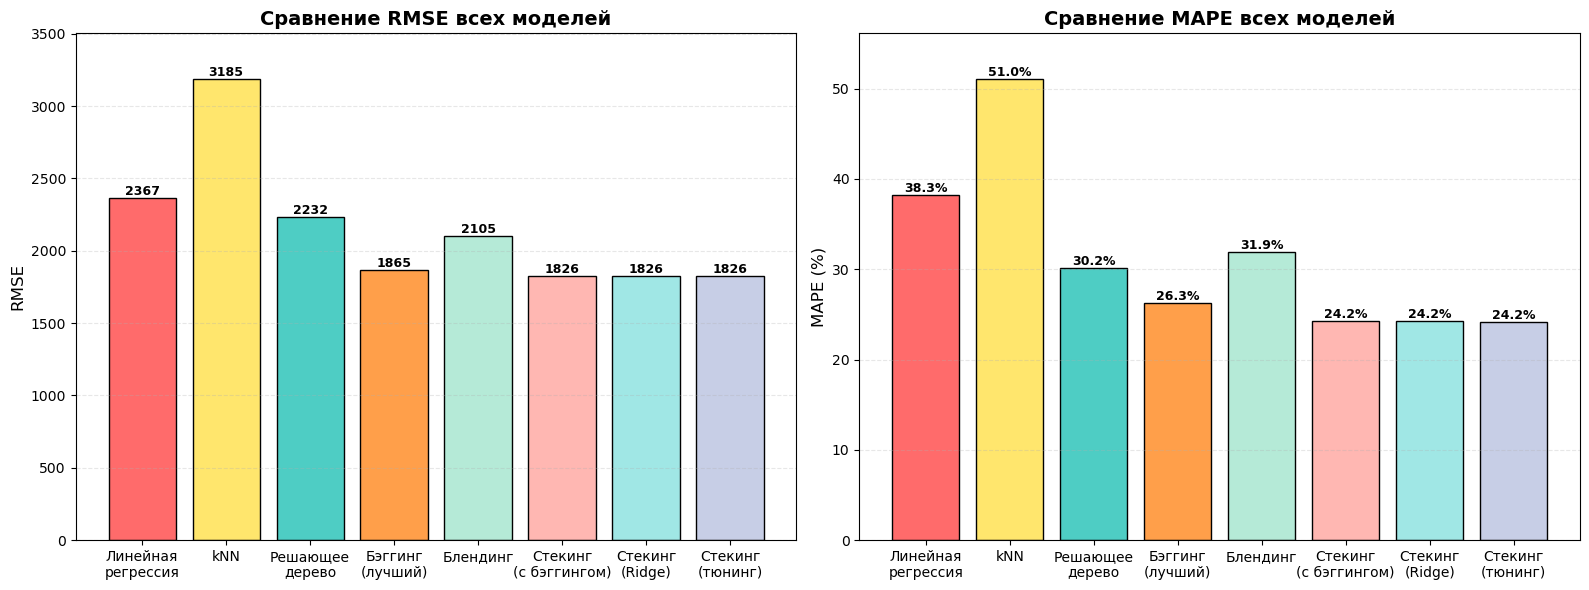


ЛУЧШАЯ МОДЕЛЬ ПО RMSE: Стекинг (тюнинг) (1825.52)
ЛУЧШАЯ МОДЕЛЬ ПО MAPE: Стекинг (тюнинг) (24.20%)


In [64]:
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ")

print("\n1. БАЗОВЫЕ МОДЕЛИ:")
print(f"Линейная регрессия:      RMSE = {rmse_lr:.2f}, MAPE = {mape_lr*100:.2f}%")
print(f"kNN:                     RMSE = {rmse_knn:.2f}, MAPE = {mape_knn*100:.2f}%")
print(f"Решающее дерево:         RMSE = {rmse_dt:.2f}, MAPE = {mape_dt*100:.2f}%")

print("\n2. БЭГГИНГ:")
print(f"Бэггинг (по умолчанию):  RMSE = {rmse_bagging:.2f}, MAPE = {mape_bagging*100:.2f}%")
print(f"Бэггинг (лучший):        RMSE = {rmse_best:.2f}, MAPE = {mape_best*100:.2f}%")

print(f"\n3. БЛЕНДИНГ:             RMSE = {rmse_blending:.2f}, MAPE = {mape_blending*100:.2f}%")

print("\n4. СТЕКИНГ:")
print(f"Стекинг (без бэггинга):  RMSE = {rmse_stacking:.2f}, MAPE = {mape_stacking*100:.2f}%")
print(f"Стекинг (с бэггингом):   RMSE = {rmse_stacking_bagging:.2f}, MAPE = {mape_stacking_bagging*100:.2f}%")
print(f"Стекинг (Ridge):         RMSE = {rmse_stacking_ridge:.2f}, MAPE = {mape_stacking_ridge*100:.2f}%")
print(f"Стекинг (Random Forest): RMSE = {rmse_stacking_rf:.2f}, MAPE = {mape_stacking_rf*100:.2f}%")
print(f"Стекинг (тюнинг):        RMSE = {rmse_stacking_tuned:.2f}, MAPE = {mape_stacking_tuned*100:.2f}%")

print("\n5. ДЕРЕВО:")
print(f"Тюнингованное дерево:    RMSE = {rmse_dt_tuned:.2f}, MAPE = {mape_dt_tuned*100:.2f}%")


all_rmse = {
    'Линейная регрессия': rmse_lr,
    'kNN': rmse_knn,
    'Решающее дерево': rmse_dt,
    'Бэггинг (лучший)': rmse_best,
    'Блендинг': rmse_blending,
    'Стекинг (с бэггингом)': rmse_stacking_bagging,
    'Стекинг (тюнинг)': rmse_stacking_tuned
}

all_mape = {
    'Линейная регрессия': mape_lr*100,
    'kNN': mape_knn*100,
    'Решающее дерево': mape_dt*100,
    'Бэггинг (лучший)': mape_best*100,
    'Блендинг': mape_blending*100,
    'Стекинг (с бэггингом)': mape_stacking_bagging*100,
    'Стекинг (тюнинг)': mape_stacking_tuned*100
}

all_models = [
    'Линейная\nрегрессия',
    'kNN',
    'Решающее\nдерево',
    'Бэггинг\n(лучший)',
    'Блендинг',
    'Стекинг\n(с бэггингом)',
    'Стекинг\n(Ridge)',
    'Стекинг\n(тюнинг)'
]

rmse_all = [rmse_lr, rmse_knn, rmse_dt, rmse_best, rmse_blending, rmse_stacking_bagging, rmse_stacking_ridge, rmse_stacking_tuned]
mape_all = [mape_lr*100, mape_knn*100, mape_dt*100, mape_best*100, mape_blending*100, mape_stacking_bagging*100, mape_stacking_ridge*100, mape_stacking_tuned*100]

colors = ['#FF6B6B', '#FFE66D', '#4ECDC4', '#FF9F4A', '#B5EAD7', '#FFB7B2', '#A0E7E5', '#C7CEE6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

bars1 = ax1.bar(all_models, rmse_all, color=colors, edgecolor='black', linewidth=1)
ax1.set_title('Сравнение RMSE всех моделей', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_ylim(0, max(rmse_all) * 1.1)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar, value in zip(bars1, rmse_all):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

bars2 = ax2.bar(all_models, mape_all, color=colors, edgecolor='black', linewidth=1)
ax2.set_title('Сравнение MAPE всех моделей', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_ylim(0, max(mape_all) * 1.1)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar, value in zip(bars2, mape_all):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

best_rmse_model = min(all_rmse, key=all_rmse.get)
best_rmse_value = all_rmse[best_rmse_model]
best_mape_model = min(all_mape, key=all_mape.get)
best_mape_value = all_mape[best_mape_model]
print(f"\nЛУЧШАЯ МОДЕЛЬ ПО RMSE: {best_rmse_model} ({best_rmse_value:.2f})")
print(f"ЛУЧШАЯ МОДЕЛЬ ПО MAPE: {best_mape_model} ({best_mape_value:.2f}%)")

### Выводы из сравнения моделей

#### Лучший результат
Наилучшие результаты показали:
- Стекинг (с бэггингом) 
- Стекинг (Ridge)
- Стекинг (тюнинг)

Разница между топ-3 вариантами в пределах 0.1% - они эквивалентны. Все 3 варианта можно считать лучшими.

#### Сравнение ансамблей
- **Bagging** — простой и надёжный: даже без тюнинга дал сильный результат. Минус: все базовые модели одного типа.
- **Blending** — хуже бэггинга. Проще стекинга, позволяет использовать разные типы моделей, но фиксированное разбиение оставляет меньше данных для мета-модели.
- **Stacking** — без сильной модели в ансамбле не даёт преимущества. С добавлением бэггинга становится лучшим по метрикам, самым гибким, позволяет комбинировать любые модели, но его настройка сложнее.

#### Высокий MAPE
MAPE = 24% - это нормально. Объяснение:
- В датасете разброс цен от £400 до £34 000 - на дешёвых авто ошибка в процентах всегда выше, даже при хорошей абсолютной точности.
- Нет многих важных признаков: состояние авто, комплектация, история обслуживания.
- ~3 700 записей - для ML это небольшой объём, сложные модели не раскрывают потенциал.

Качество модели можно считать удовлетворительным, но не идеальным.  


## Практическая значимость

Модель с ошибкой RMSE ~£1825 позволяет оценить автомобиль с точностью ±10–15% от реальной цены - этого достаточно для первичного ориентира на платформе. Результат позволяет выделить переоценённые или недооценённые объявления на платформе и ускорить сделки. Стекинг с бэггингом автоматически комбинирует слабые и сильные модели, находя оптимальные веса без ручного подбора - архитектура не привязана к конкретному датасету и легко переиспользуется при добавлении новых признаков (состояние, комплектация, регион).
